# Data augmentation for the dataset

In [2]:
import pydicom
import cv2
import numpy as np
import albumentations as A
import os
import pandas as pd

csv_path = 'INbreast Release 1.0/INbreast.csv'
df = pd.read_csv(csv_path, delimiter=';')
df.columns = df.columns.str.strip()  # remove whitespace from column names
print(f"Total images in CSV: {len(df)}")

image_dir = 'INbreast Release 1.0/AllDICOMs'
output_dir = 'augmented_images'
os.makedirs(output_dir, exist_ok=True)

dicom_files = [f for f in os.listdir(image_dir) if f.endswith('.dcm')]

# build a mapping from file number to full DICOM filename
file_number_to_dicom = {}
for f in dicom_files:
    num = f.split('_')[0]
    file_number_to_dicom[num] = f

print(f"Number of unique DICOM file numbers: {len(file_number_to_dicom)}")

# augmentation pipeline (randomly flip, brightness/contrast, rotation, noise)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(p=0.2)
])

augmented_rows = []
for idx, row in df.iterrows():
    file_number = str(row.get('File Name', '')).strip()
    label = str(row.get('Bi-Rads', '')).strip()
    dicom_filename = file_number_to_dicom[file_number]
    dicom_path = os.path.join(image_dir, dicom_filename)
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    img = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX)
    orig_png_path = os.path.join(output_dir, f"{file_number}_orig.png")
    cv2.imwrite(orig_png_path, (img * 255).astype(np.uint8))
    augmented_rows.append({'image_path': orig_png_path, 'label': label})
    for i in range(3):
        augmented = augment(image=img)['image']
        aug_png_path = os.path.join(output_dir, f"{file_number}_aug{i}.png")
        cv2.imwrite(aug_png_path, (augmented * 255).astype(np.uint8))
        augmented_rows.append({'image_path': aug_png_path, 'label': label})

aug_df = pd.DataFrame(augmented_rows)
print(f"Total images after augmentation: {len(aug_df)}")

Total images in CSV: 410
Number of unique DICOM file numbers: 410
Total images after augmentation: 1640
Total images after augmentation: 1640


In [3]:
from tqdm import tqdm

resize_dim = (224, 224)
valid_paths = aug_df['image_path'].apply(lambda x: isinstance(x, str) and os.path.isfile(x))
for img_path in tqdm(aug_df.loc[valid_paths, 'image_path'], desc='Resizing images'):
    img = cv2.imread(img_path)
    if img is not None:
        resized_img = cv2.resize(img, resize_dim, interpolation=cv2.INTER_AREA)
        cv2.imwrite(img_path, resized_img)
    else:
        print(f"Warning: Could not read {img_path}")
print("All images resized to 224x224.")

Resizing images:   0%|          | 0/1640 [00:00<?, ?it/s]

Resizing images: 100%|██████████| 1640/1640 [03:39<00:00,  7.46it/s]

All images resized to 224x224.


In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    aug_df[['image_path', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=aug_df['label']
)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

Train set: 1312 samples
Test set: 328 samples


In [16]:
def is_int_label(x):
    try:
        int(x)
        return True
    except:
        return False

# Clean train_df and test_df to keep only integer labels
train_df_clean = train_df[train_df['label'].apply(is_int_label)].copy()
test_df_clean = test_df[test_df['label'].apply(is_int_label)].copy()

num_dropped_train = len(train_df) - len(train_df_clean)
num_dropped_test = len(test_df) - len(test_df_clean)
if num_dropped_train > 0 or num_dropped_test > 0:
    print(f"Dropped {num_dropped_train} train and {num_dropped_test} test samples with non-integer labels.")

# Use these cleaned DataFrames in the rest of the notebook
train_df = train_df_clean
test_df = test_df_clean

Dropped 138 train and 34 test samples with non-integer labels.


In [ ]:
# Remap labels from 1-6 to 0-5 for Keras compatibility
train_df['label'] = train_df['label'].astype(int) - 1
test_df['label'] = test_df['label'].astype(int) - 1

# Check for out-of-range labels
if train_df['label'].min() < 0 or train_df['label'].max() > 5:
    print('Warning: Some labels are out of the expected range 0-5 after remapping.')

# Preview image set

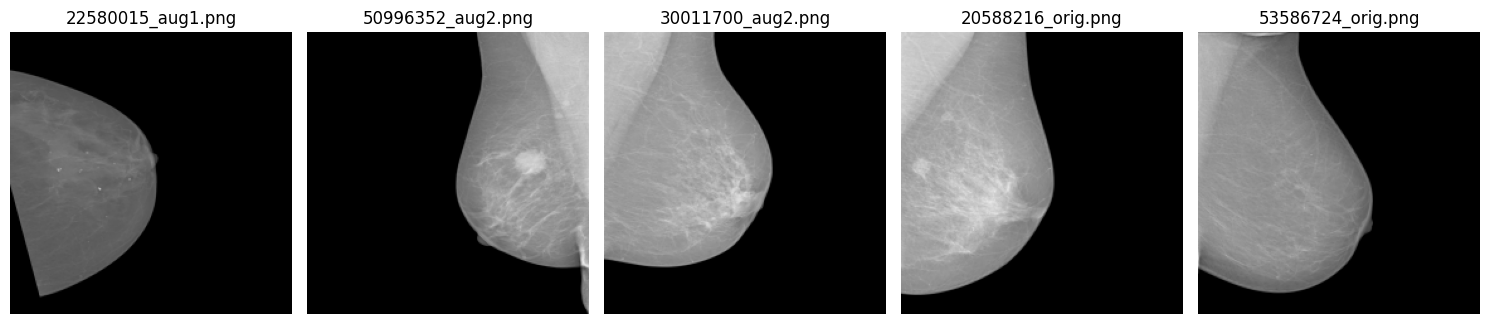

In [17]:
# see random sample of augmented images
import random
import matplotlib.pyplot as plt

sample_images = random.sample(list(aug_df['image_path']), 5)
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocessing

## Denoise

In [18]:
def denoise_image(image, kernel_size=(5, 5), sigma=0, show=False):
    if show:
        denoised = cv2.GaussianBlur(image, kernel_size, sigma)
        plt.imshow(denoised, cmap='gray')
        plt.title('Denoised Image')
        plt.axis('off')
        plt.show()
        return denoised
    else: 
        return cv2.GaussianBlur(image, kernel_size, sigma)

## Binarization

In [19]:
# Função de binarização (thresholding)
def binarize_image(image, threshold=127, max_value=255, method=cv2.THRESH_BINARY, show=False):
    _, binary = cv2.threshold(image, threshold, max_value, method)
    if show:
        plt.imshow(binary, cmap='gray')
        plt.title('Binarized Image')
        plt.axis('off')
        plt.show()
    return binary

## Lowpass filter

In [20]:
def lowpass_filter(image, kernel_size=(5, 5), show=False):
    blurred = cv2.blur(image, kernel_size)
    if show:
        plt.imshow(blurred, cmap='gray')
        plt.title('Low-pass Filtered Image')
        plt.axis('off')
        plt.show()
    return blurred

## Morphological operations

In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def erode_image(image, kernel_size=(5, 5), iterations=1, show=False):
    kernel = np.ones(kernel_size, np.uint8)
    if show:
        eroded = cv2.erode(image, kernel, iterations=iterations)
        plt.imshow(eroded, cmap='gray')
        plt.title('Eroded Image')
        plt.axis('off')
        plt.show()
        return eroded
    else:
        return cv2.erode(image, kernel, iterations=iterations)

def dilate_image(image, kernel_size=(5, 5), iterations=1, show=False):
    kernel = np.ones(kernel_size, np.uint8)
    if show:
        dilated = cv2.dilate(image, kernel, iterations=iterations)
        plt.imshow(dilated, cmap='gray')
        plt.title('Dilated Image')
        plt.axis('off')
        plt.show()
        return dilated
    else:
        return cv2.dilate(image, kernel, iterations=iterations)
    
def open_image(image, kernel_size=(5, 5), iterations=1, show=False):
    kernel = np.ones(kernel_size, np.uint8)
    if show:
        opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        plt.imshow(opened, cmap='gray')
        plt.title('Opened Image')
        plt.axis('off')
        plt.show()
        return opened
    else:
        return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    
def close_image(image, kernel_size=(5, 5), iterations=1, show=False):
    kernel = np.ones(kernel_size, np.uint8)
    if show:
        closed = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
        plt.imshow(closed, cmap='gray')
        plt.title('Closed Image')
        plt.axis('off')
        plt.show()
        return closed
    else:
        return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)


## Running over Keras network

### Results Interpretation

The table above shows the best validation accuracy achieved for each preprocessing method. The method with the highest value is the best candidate for preprocessing in this classification task.

In [22]:
# Define wrappers for each preprocessing operation
def identity(img):
    return img

def denoise_wrapper(img):
    return denoise_image(img)

def binarize_wrapper(img):
    return binarize_image(img)

def lowpass_wrapper(img):
    return lowpass_filter(img)

def erode_wrapper(img):
    return erode_image(img)

def dilate_wrapper(img):
    return dilate_image(img)

def open_wrapper(img):
    return open_image(img)

def close_wrapper(img):
    return close_image(img)

preprocessing_methods = {
    'none': identity,
    'denoise': denoise_wrapper,
    'binarize': binarize_wrapper,
    'lowpass': lowpass_wrapper,
    'erode': erode_wrapper,
    'dilate': dilate_wrapper,
    'open': open_wrapper,
    'close': close_wrapper
}

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_model(input_shape=(224, 224, 1), num_classes=6):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        BatchNormalization(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [24]:
import cv2
import numpy as np
from tqdm import tqdm

def preprocess_images(df, preprocess_fn, color_mode='grayscale', resize_dim=(224, 224)):
    X = []
    y = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE if color_mode=='grayscale' else cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.resize(img, resize_dim)
        img = preprocess_fn(img)
        X.append(img)
        y.append(int(row['label']))
    X = np.array(X)
    y = np.array(y)
    if color_mode == 'grayscale':
        X = X[..., np.newaxis]  # add channel axis
    return X, y

In [25]:
from sklearn.model_selection import train_test_split
import pandas as pd

results = []

for name, preprocess_fn in preprocessing_methods.items():
    print(f"\n=== Preprocessing: {name} ===")
    # Preprocess images
    X_train, y_train = preprocess_images(train_df, preprocess_fn)
    X_test, y_test = preprocess_images(test_df, preprocess_fn)
    # Normalize to [0,1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    # Build and train model
    model = build_model(input_shape=X_train.shape[1:], num_classes=6)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=5,  # Use more epochs for real experiments
        batch_size=32,
        verbose=2
    )
    best_val_acc = max(history.history['val_accuracy'])
    results.append({'preprocessing': name, 'best_val_accuracy': best_val_acc})
    print(f"Best val accuracy for {name}: {best_val_acc:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('best_val_accuracy', ascending=False)
results_df


=== Preprocessing: none ===


100%|██████████| 1174/1174 [00:01<00:00, 599.82it/s]

100%|██████████| 294/294 [00:00<00:00, 569.00it/s]

/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-30 23:57:49.249520: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__ini

Epoch 1/5


2025-06-30 23:57:49.782087: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 235626496 exceeds 10% of free system memory.
2025-06-30 23:57:52.774386: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 201867264 exceeds 10% of free system memory.
2025-06-30 23:57:52.774386: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 201867264 exceeds 10% of free system memory.
2025-06-30 23:57:53.110926: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 97329152 exceeds 10% of free system memory.
2025-06-30 23:57:53.110926: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 97329152 exceeds 10% of free system memory.
2025-06-30 23:57:53.349536: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 6 which is outside the valid range of [0, 6).  Label values: 1 2 2 2 5 2 1 2 

InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/pedrofbv/repos/breast_cancer_analysis/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_eve

## Preprocessing Comparison Workflow

We will now apply each preprocessing operation (denoise, binarization, lowpass filter, morphological operations) to the dataset, train the Keras model on each preprocessed version, and compare their validation accuracy to determine the best approach.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Example image size (adjust to yours: 224x224 or 512x512, for example)
IMG_HEIGHT, IMG_WIDTH = 224, 224
CHANNELS = 1  # Grayscale X-rays
NUM_CLASSES = 6  # Multi-class (6 output classes)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    MaxPooling2D(2,2),
    BatchNormalization(),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')  # Multi-class softmax output
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()
